# imports

In [2]:
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

/home/khalidraisi/.conda/envs/532env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load model and datasets

In [2]:
model_name = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

#harmful prompts
advbench = load_dataset("walledai/AdvBench")
harmful_prompts = advbench['train']['prompt']

#harmless prompts
alpaca = load_dataset("tatsu-lab/alpaca")
harmless_prompts = [entry['instruction'] for entry in alpaca['train']]

#utility prompts
helpsteer = load_dataset("nvidia/HelpSteer")
utility_prompts = [entry['prompt'] for entry in helpsteer['train']]

N = 100
harmful_prompts = harmful_prompts[:N]
harmless_prompts = harmless_prompts[:N]
utility_prompts = utility_prompts[:N]

Loading weights: 100%|██████████| 340/340 [00:13<00:00, 24.51it/s]


# Get activations from all layers 

In [3]:
def get_activations(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    return [h[:, -1, :].float().cpu().numpy()[0] for h in outputs.hidden_states]

# store all activations from respective dataset
harmful = np.array([get_activations(prompt) for prompt in tqdm(harmful_prompts, desc="harmful")])
harmless = np.array([get_activations(prompt) for prompt in tqdm(harmless_prompts, desc="harmless")])
utility = np.array([get_activations(prompt) for prompt in tqdm(utility_prompts, desc="utility")])

np.save("harmful_activations.npy", harmful)
np.save("harmless_activations.npy", harmless)
np.save("utility_activations.npy", utility)

utility: 100%|██████████| 100/100 [34:12<00:00, 20.52s/it]


# Implement and apply DoM then use cosine similarity on extracted directions

In [4]:
# all have the same size/shape anyways
num_layers = harmful.shape[1]
cosine_similarities = []

#This is same as what was put previously in EDA.ipynb just modified for all layers
for layer in range(num_layers):
    # mean of activations
    harm_mean = harmful[:, layer, :].mean(axis=0)
    help_mean = utility[:, layer, :].mean(axis=0)
    alp_mean = harmless[:, layer, :].mean(axis=0)

    #DoM here extract safety/utility directions 
    refusal_direction = harm_mean - alp_mean
    utility_direction = help_mean - alp_mean

    #for neater results normalize and also recall with cosine similarity that closer to 0 means closer to being independent
    refusal_direction /= np.linalg.norm(refusal_direction)
    utility_direction /= np.linalg.norm(utility_direction)
    cosine_similarities.append(np.dot(refusal_direction, utility_direction))

# ActSVD
Wei et al have 2 versions, they call them ActSVD (Top) as well as ActSVD (with orthogonal projection) \
They describe ActSVD (Top) as it gives you the top k principal components forming the k-dimensional subspace, and "top" refers to the ranking of singular values and their respective principal components \
They describe ActSVD (Orthogonal projection) as it gives you the part of the safety subspace that does not overlap with utility \
Both are useful for our purposes (with a bit of tweaking)

In [ ]:
#subspace dimension, n, worth playing around with this, safetry critical regions are low rank
k = 10

safety_subspace = []
utility_subspace = []

for layer in range(num_layers):
    #ActSVD (Top)
    #get all activations and transpose
    #perform svd (U S VT = W @ X_in) on both and then we take the vectors corresponding to the highest ranked singular values (top k) forming our subspaces for both safety and utility

    
    #ActSVD (Orthogonal projection)
    # projection utility/safety matrix is U @ U.T
    # then we subtract this part that overlaps (the projection utility matrix)

# Plots and other stuff

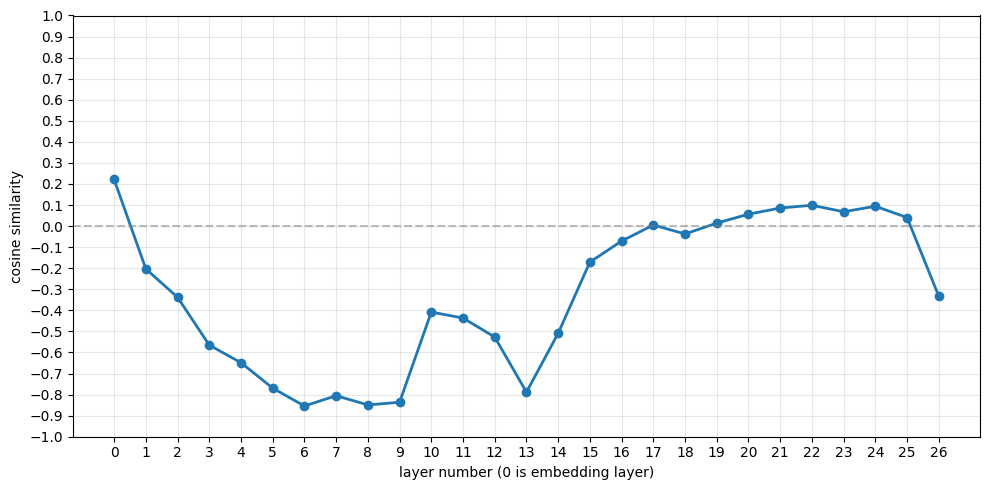

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_layers), cosine_similarities, marker='o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("layer number (0 is embedding layer)")
plt.ylabel("cosine similarity")
plt.xticks(range(0, num_layers, 1))
plt.yticks(np.arange(-1, 1.1, 0.1))
plt.grid(True, alpha=0.3)
plt.tight_layout()

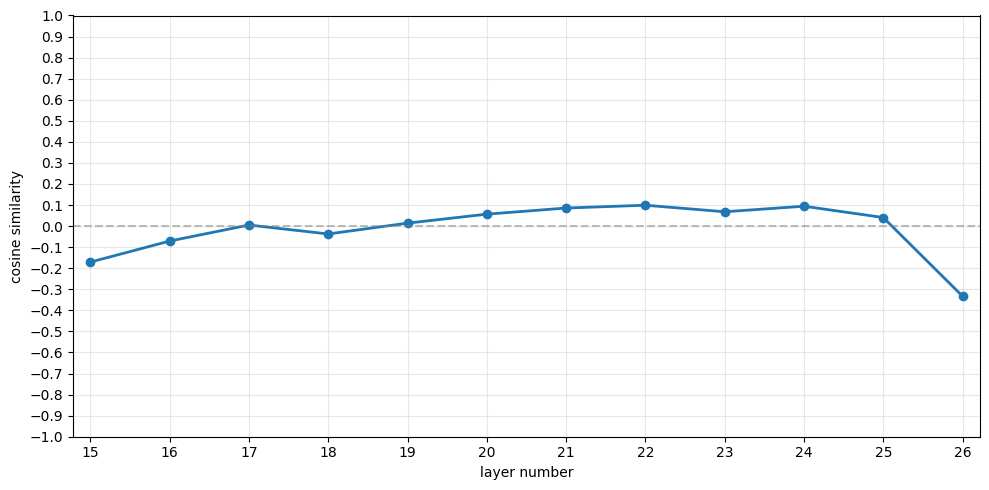

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(15, num_layers), cosine_similarities[15:], marker='o', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("layer number")
plt.ylabel("cosine similarity")
plt.xticks(range(15, num_layers, 1))
plt.yticks(np.arange(-1, 1.1, 0.1))
plt.grid(True, alpha=0.3)
plt.margins(x=0.02)
plt.tight_layout()
plt.show()

In [7]:
for i, cos_sim in enumerate(cosine_similarities):
    print(f"layer {i} cosine similarity: {cos_sim:.4f}")

layer 0 cosine similarity: 0.2213
layer 1 cosine similarity: -0.2033
layer 2 cosine similarity: -0.3381
layer 3 cosine similarity: -0.5650
layer 4 cosine similarity: -0.6486
layer 5 cosine similarity: -0.7694
layer 6 cosine similarity: -0.8542
layer 7 cosine similarity: -0.8051
layer 8 cosine similarity: -0.8491
layer 9 cosine similarity: -0.8363
layer 10 cosine similarity: -0.4081
layer 11 cosine similarity: -0.4365
layer 12 cosine similarity: -0.5268
layer 13 cosine similarity: -0.7883
layer 14 cosine similarity: -0.5090
layer 15 cosine similarity: -0.1708
layer 16 cosine similarity: -0.0710
layer 17 cosine similarity: 0.0052
layer 18 cosine similarity: -0.0373
layer 19 cosine similarity: 0.0142
layer 20 cosine similarity: 0.0567
layer 21 cosine similarity: 0.0858
layer 22 cosine similarity: 0.0991
layer 23 cosine similarity: 0.0682
layer 24 cosine similarity: 0.0944
layer 25 cosine similarity: 0.0409
layer 26 cosine similarity: -0.3328
